In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

model = joblib.load('../models/champion_model.pkl')
threshold = joblib.load('../models/champion_threshold.pkl')

print(f'Loaded model with threshold = {threshold:.3f}')

Loaded model with threshold = 0.267


In [2]:
#Extracting and sorting coefficients
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
coefficients['abs_coefficient'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('abs_coefficient', ascending=False)

coefficients.head(20)

,feature,coefficient,abs_coefficient
17,merchant_risk_score,1.059669,1.059669
12,cvv_retry_count,0.851562,0.851562
13,velocity_score,0.842404,0.842404
8,is_new_merchant,0.615609,0.615609
10,ip_country_mismatch,0.612397,0.612397
11,billing_shipping_mismatch,0.553069,0.553069
35,auth_method_No Authentication,0.524380,0.524380
9,used_vpn,0.466353,0.466353
34,auth_method_Biometric,-0.426531,0.426531
16,is_ai_generated_scam_attempt,0.368698,0.368698


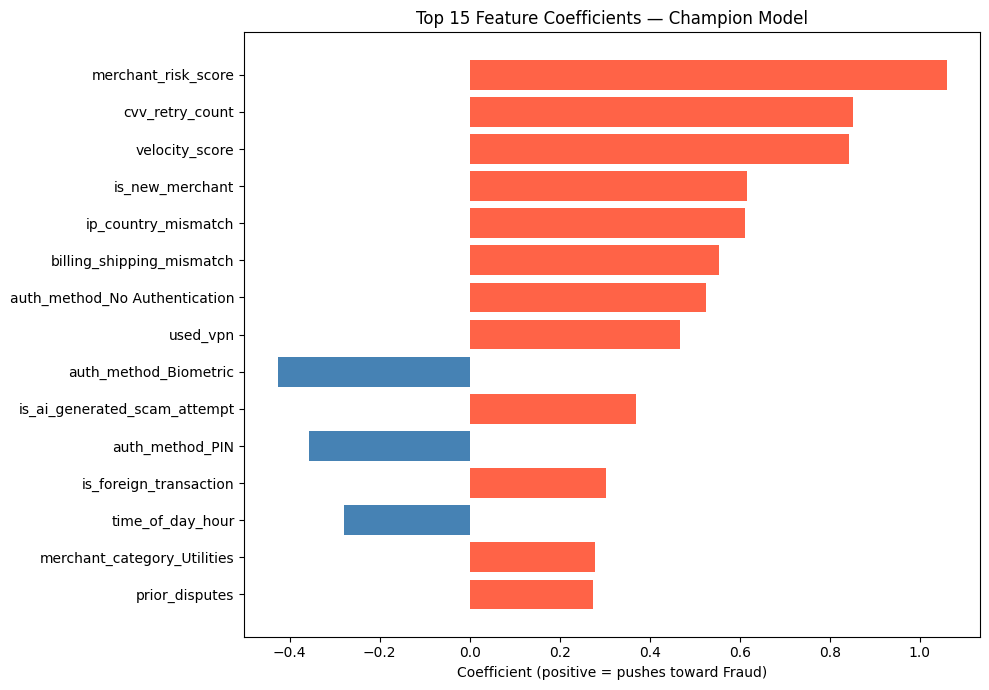

In [3]:
#Visualizing the top 15 most influential features
top_features = coefficients.head(15)

plt.figure(figsize=(10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.xlabel('Coefficient (positive = pushes toward Fraud)')
plt.title('Top 15 Feature Coefficients — Champion Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
#How many features did L1 zero out entirely
zeroed = (coefficients['coefficient'] == 0).sum()
print(f'{zeroed} out of {len(coefficients)} features were zeroed out by L1 regularization')
print()
print('Features the model considers completely irrelevant:')
print(coefficients[coefficients['coefficient'] == 0]['feature'].tolist())

0 out of 49 features were zeroed out by L1 regularization

Features the model considers completely irrelevant:
[]
